In [2]:
# A décommenter à la première exécution si jupyter se plaint de ne pas trouver oracledb
#!pip install --upgrade oracledb

In [1]:
# Compléter ici les imports dont vous avez besoin, ne pas modifier ceux déjà présents
import getpass
from os import getenv
import pandas as pd
import oracledb
import warnings
import matplotlib.pyplot as plt

In [2]:
# Nécessaire pour éviter les problèmes de session
class Connexion(object):
    def __init__(self, login, password):
        self.conn = oracledb.connect(
            user=login,
            password=password,
            host="oracle.iut-orsay.fr",
            port=1521,
            sid="etudom",
        )
        self.conn.autocommit = False

    def __enter__(self):
        self.conn.autocommit = False
        return self.conn

    def __exit__(self, *args):
        self.conn.close()

In [3]:
# La fonction ci-dessous est à utiliser pour exécuter une requête et stocker les résultats dans un dataframe Pandas sans afficher d’alerte.
# Vous pouvez vous en inspirer pour créer vos propres fonctions.
def requete_vers_dataframe(connexion_data, requete, valeurs = None):
    with Connexion(login=connexion_data['login'], password=connexion_data['password']) as connexion:
        warnings.simplefilter(action='ignore', category=UserWarning)
        if valeurs is not None:
            df = pd.read_sql(requete, connexion, params=valeurs)
        else:
            df = pd.read_sql(requete, connexion)
        warnings.simplefilter("always") 
        return df

In [7]:
# Saisir ci-dessous la plateforme qui vous a été attribuée. Cela correspond au nomPlateforme dans la table PLATEFORME de la base de données
# Par exemple NOM_PLATEFORME = "Switch"
NOM_PLATEFORME = "Nintendo Entertainment System"
# Saisir ci-dessous le login court de la base utilisée pour votre carnet
SCHEMA = '"PSOUNOU"'

# TABLEAU DE BORD PLATEFORME

## Partie consultation des données

In [5]:
# On demande à l'utilisateur son login et mot de passe pour pouvoir accéder à la base de données
if getenv("DB_LOGIN") is None:
    login = input("Login : ")
else:
    login = getenv("DB_LOGIN")
if getenv("DB_PASS") is None:
    password = getpass.getpass("Mot de passe : ")
else:
    password = getenv("DB_PASS")
conn = {'login': login, 'password': password}

Login :  psounou
Mot de passe :  ········


In [8]:
# On vérifie que l'utilisateur est bien connecté à la base de données, que le schéma est bon, et qu'on trouve la bonne plateforme
data = requete_vers_dataframe(conn, f"SELECT * FROM {SCHEMA}.PLATEFORME WHERE nomPlateforme LIKE (:libelle)",{"libelle":NOM_PLATEFORME})
id_plateforme = int(data.IDPLATEFORME.iloc[0])
print(f"Identifiant de la plateforme : {id_plateforme}")

Identifiant de la plateforme : 18


### Statistiques de base

#### Nombre de jeux publiés sur cette plateforme

In [9]:
# Calculer avec une requête et afficher le nombre de jeux publiés sur cette plateforme
data = requete_vers_dataframe(conn, f"""
SELECT COUNT(DISTINCT J.idJeu) as nb
FROM {SCHEMA}.JEU J
INNER JOIN {SCHEMA}.DATESORTIE DS ON J.idJeu=DS.idJeu
INNER JOIN {SCHEMA}.PLATEFORME P ON DS.idPlateforme=P.idPlateforme
WHERE nomPlateforme='Nintendo Entertainment System'""")  
print(data);

     NB
0  1403


#### Nombre de compagnies ayant développé sur cette plateforme

In [10]:
# Calculer avec une requête et afficher le nombre de compagnies ayant développé sur cette plateforme
data = requete_vers_dataframe(conn, f"""
SELECT COUNT(DISTINCT C.idCompagnie) AS "Nombre de compagnies"
FROM {SCHEMA}.COMPAGNIEJEU C
INNER JOIN {SCHEMA}.DATESORTIE D ON C.idJeu = D.idJeu
WHERE IdPlateforme = :id
""", {"id": id_plateforme})
data

,Nombre de compagnies
0,715


### Jeux

#### Répartition des jeux par année

In [11]:
# Calculer avec une requête et afficher le nombre de jeux publiés par année sur cette plateforme
data = requete_vers_dataframe(conn, f"""
    SELECT
        TO_CHAR(DateSortie, 'YYYY') AS "Année",
        COUNT(DISTINCT IdJeu) AS "Nombre de jeux"
    FROM {SCHEMA}.DateSortie
    WHERE IdPlateforme = :id
    GROUP BY TO_CHAR(DateSortie, 'YYYY')
    ORDER BY "Année"
""", {"id": id_plateforme})
data

,Année,Nombre de jeux
0,0028,1
1,1984,1
2,1985,21
3,1986,35
4,1987,65
5,1988,88
6,1989,120
7,1990,208
8,1991,209
9,1992,144


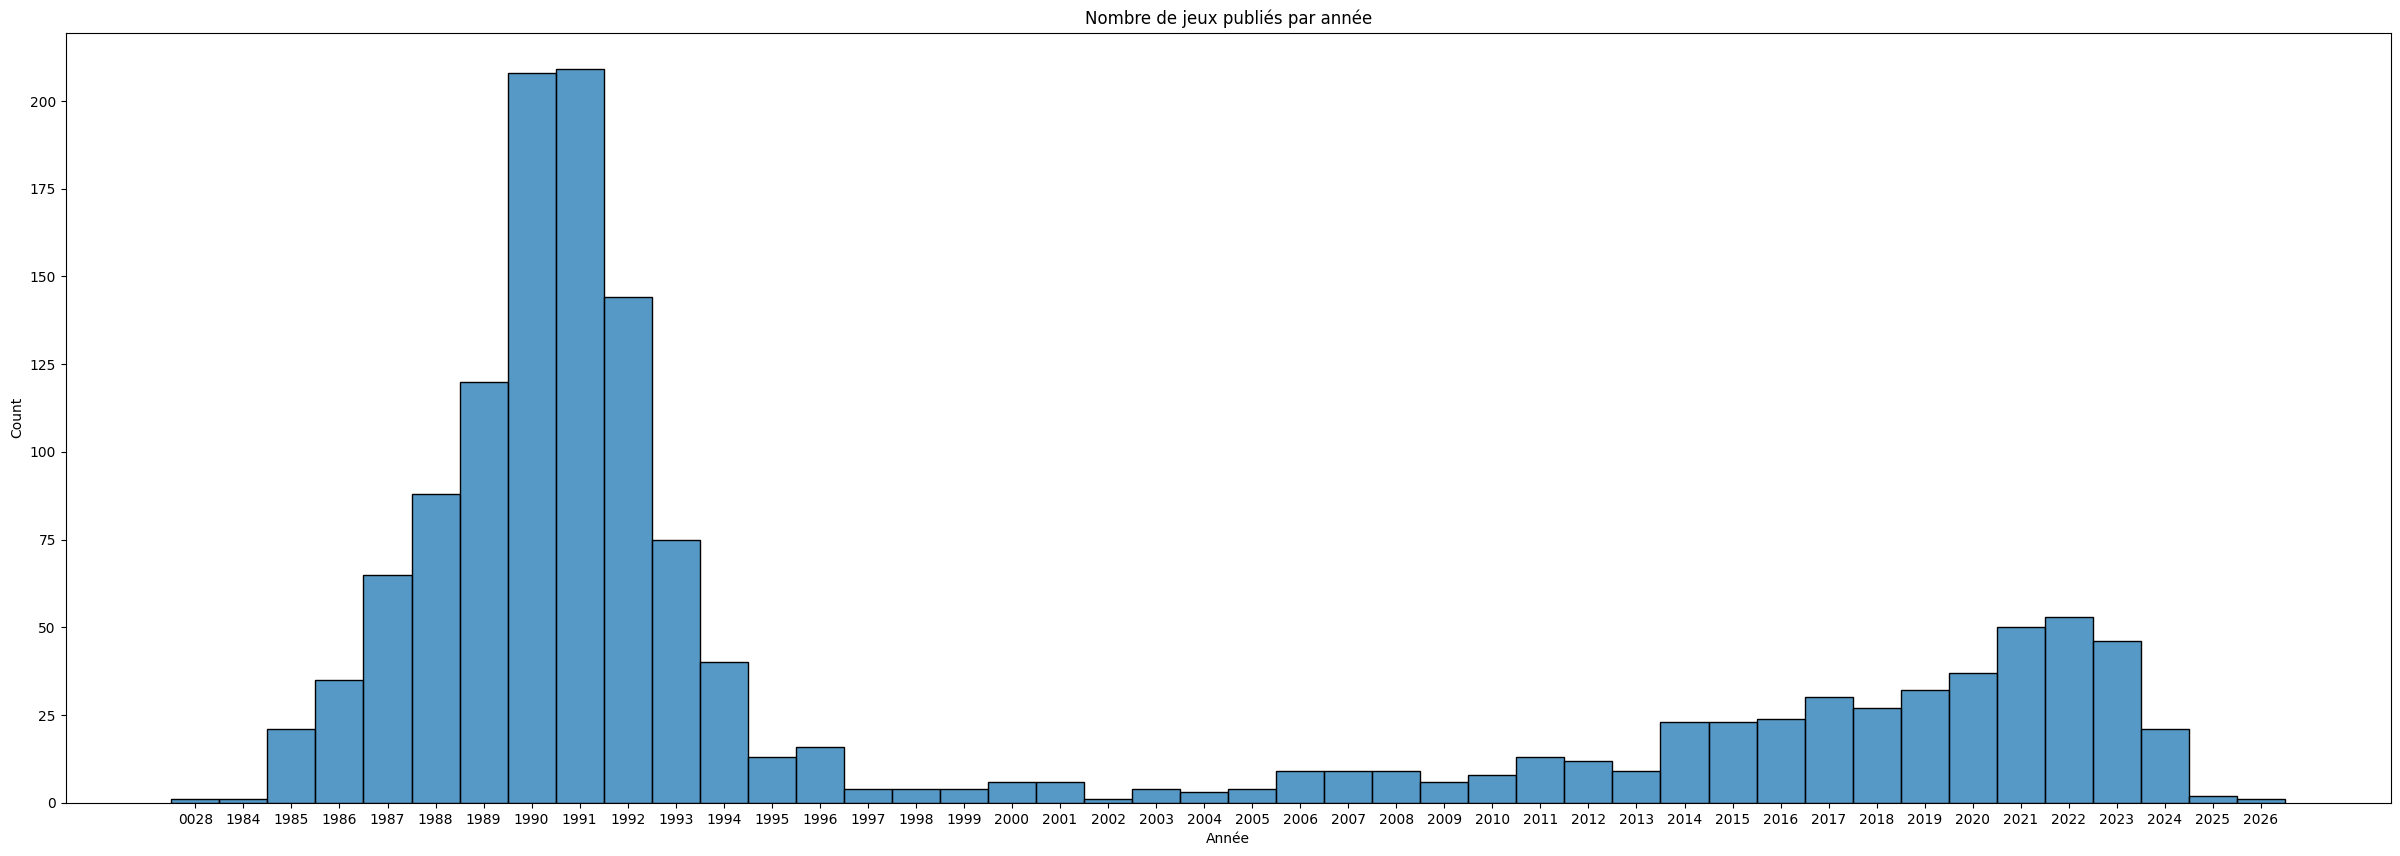

In [12]:
# Faire un histogramme des sorties par année
import seaborn as sns
import matplotlib.pyplot as plt

data = requete_vers_dataframe(conn, f"""
    SELECT
        TO_CHAR(DateSortie, 'YYYY') AS "Année",
        COUNT(DISTINCT IdJeu) AS "Nombre de jeux"
    FROM {SCHEMA}.DateSortie
    WHERE IdPlateforme = :id
    GROUP BY TO_CHAR(DateSortie, 'YYYY')
    ORDER BY "Année"
""", {"id": id_plateforme})

plt.figure(figsize=(30, 10))
sns.histplot(data=data, x="Année", weights="Nombre de jeux")


plt.title("Nombre de jeux publiés par année")
plt.show()

#### Top 10 des jeux les mieux notés par les utilisateurs sur cette plateforme

In [13]:
# Récupérer les données, les transformer si nécessaire, puis afficher sous forme de tableau
data = requete_vers_dataframe(conn, f"""
	SELECT DISTINCT Titrejeu,ScoreJeu
	FROM {SCHEMA}.JEU J
	INNER JOIN {SCHEMA}.DATESORTIE DS ON J.idJeu=DS.idJeu
	INNER JOIN {SCHEMA}.PLATEFORME P ON DS.idPlateforme=P.idPlateforme
	WHERE nomPlateforme='Nintendo Entertainment System' AND ScoreJeu IS NOT NULL
	ORDER BY ScoreJeu DESC
	""".format(NOM_PLATEFORME, SCHEMA))
data.iloc[0:10]

,TITREJEU,SCOREJEU
0,BDWarrior 2025,100.000000
1,Jurassic Park,97.665578
2,Life Force,96.981360
3,Tetris 2,89.648915
4,Super Mario Bros. 3,89.482150
5,Clash at Demonhead,88.748202
6,Arkanoid,88.292808
7,Pac-Man,87.763768
8,Banana Prince,87.057457
9,StarTropics,86.885415


#### Répartition des jeux par catégorie

In [14]:
# Récupérer les données, les transformer si nécessaire, puis afficher sous forme de tableau
data = requete_vers_dataframe(conn, f"""
    SELECT C.nomCategorieJeu AS "Catégorie", COUNT(*) AS "Nombre de jeux"
    FROM {SCHEMA}.JEU J
    JOIN {SCHEMA}.CATEGORIEJEU C ON J.CATEGORIEJEU = C.idCategorieJeu
    GROUP BY C.nomCategorieJeu
    ORDER BY "Nombre de jeux" DESC
""")
data

,Catégorie,Nombre de jeux
0,main_game,51341
1,port,5822
2,bundle,3364
3,mod,2928
4,dlc_addon,1720
5,pack,1706
6,expanded_game,841
7,remake,570
8,remaster,338
9,episode,178


### Compagnies

#### Tableau de répartition des compagnies ayant développé sur cette plateforme par pays

In [15]:
# Récupérer les données, les transformer si nécessaire, puis afficher sous forme de tableau
data_comp = requete = f"""
    SELECT DISTINCT C.NomCompagnie
    FROM {SCHEMA}.COMPAGNIE C
    INNER JOIN {SCHEMA}.COMPAGNIEJEU CJ ON CJ.IdCompagnie = C.IdCompagnie
    INNER JOIN {SCHEMA}.JEU J ON J.IdJeu = CJ.IdJeu
    INNER JOIN {SCHEMA}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {SCHEMA}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    WHERE P.NomPlateforme = :plateforme
"""
data_comp = requete_vers_dataframe(conn, requete, {"plateforme": NOM_PLATEFORME})
data_comp.iloc[0:5]

,NOMCOMPAGNIE
0,Nintendo R&D1
1,Hudson Soft
2,Majesco Entertainment
3,Tokai Engineering
4,Taito


#### Graphique : top 25 des compagnies ayant développé sur cette plateforme les mieux notées en moyenne par les utilisateurs d'IGDB

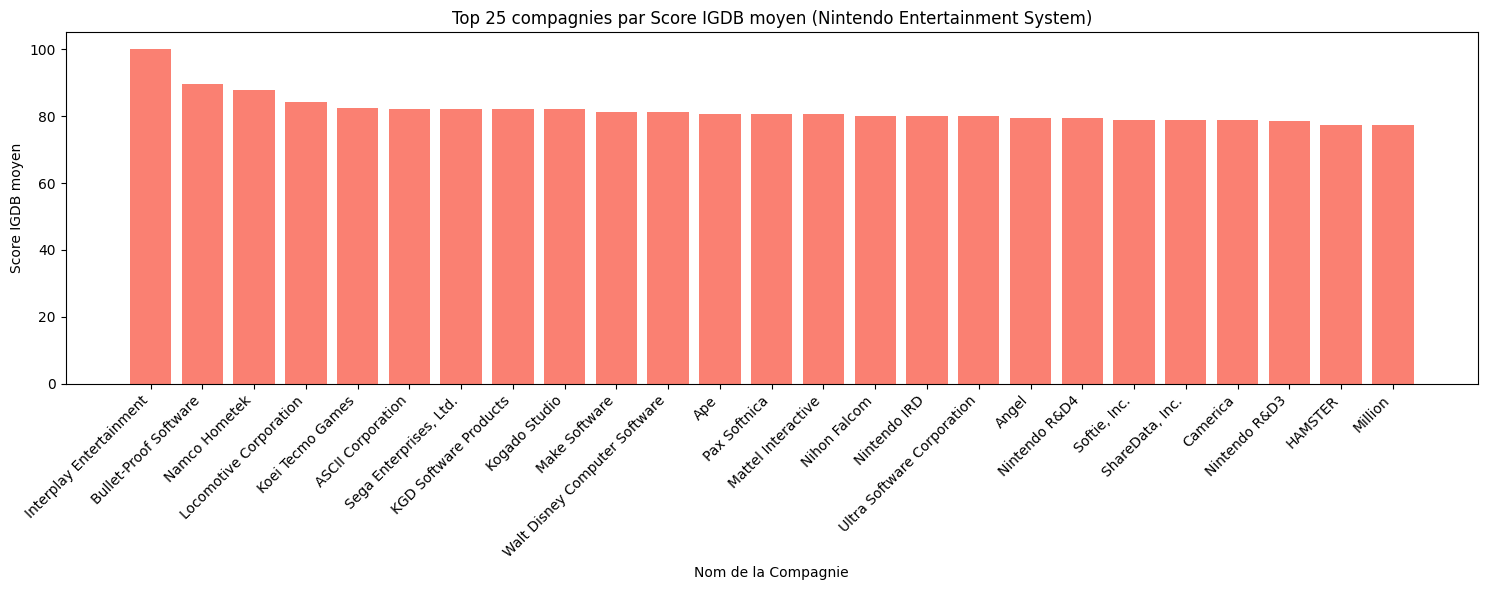

In [16]:
# Récupérer les données, les transformer si nécessaire, puis afficher sous forme de graphique
import numpy as np
import matplotlib.pyplot as plt
import sys

# Récupération des données
data_comp = requete_vers_dataframe(conn, f"""
    SELECT C.NomCompagnie, ROUND(AVG(J.ScoreIGDB), 2) AS ScoreMoyen
    FROM {SCHEMA}.COMPAGNIE C
    INNER JOIN {SCHEMA}.COMPAGNIEJEU CJ ON CJ.IdCompagnie = C.IdCompagnie
    INNER JOIN {SCHEMA}.JEU J ON J.IdJeu = CJ.IdJeu
    INNER JOIN {SCHEMA}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {SCHEMA}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    WHERE P.NomPlateforme = :plateforme
    AND J.ScoreIGDB IS NOT NULL
    GROUP BY C.NomCompagnie
    ORDER BY AVG(J.ScoreIGDB) DESC
    FETCH FIRST 25 ROWS ONLY
""", {"plateforme": NOM_PLATEFORME})



# Transformation en np.array pour matplotlib
xpoint = np.array(data_comp['NOMCOMPAGNIE'].to_list())
ypoint = np.array(data_comp['SCOREMOYEN'].to_list())

# Création du graphique
plt.figure(figsize=(15, 6))
plt.bar(xpoint, ypoint, color='salmon')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Nom de la Compagnie")
plt.ylabel("Score IGDB moyen")
plt.title(f"Top 25 compagnies par Score IGDB moyen ({NOM_PLATEFORME})")
plt.tight_layout()
plt.show()

#### Graphiques : top 25 des compagnies ayant le plus développé, top 25 des compagnies ayant le plus publié, en nombre de jeux, sur cette plateforme

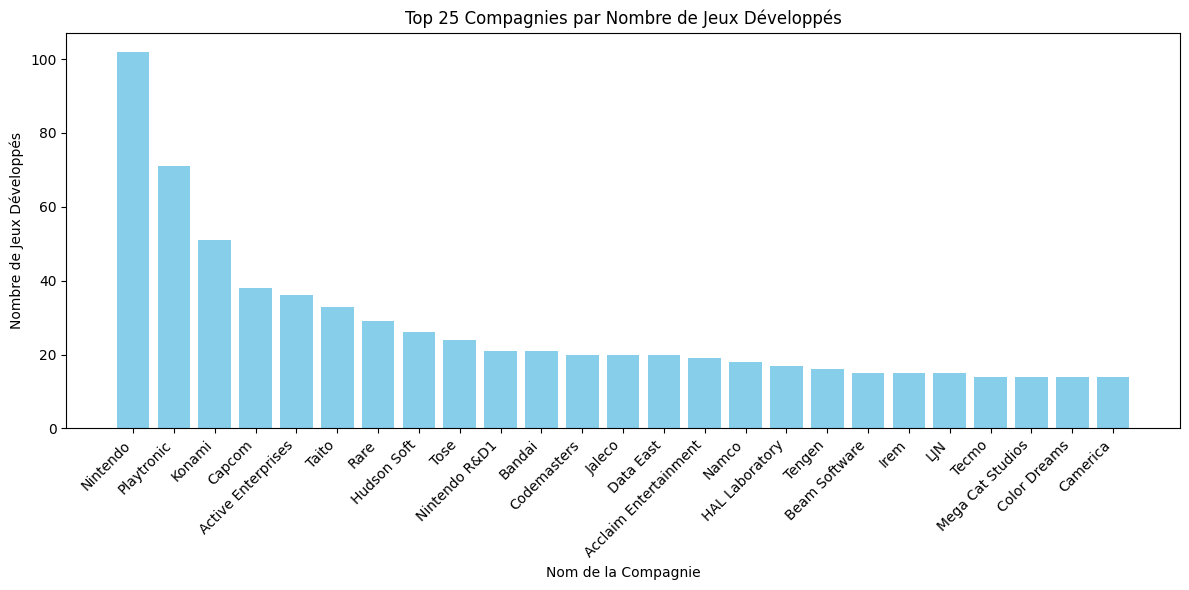

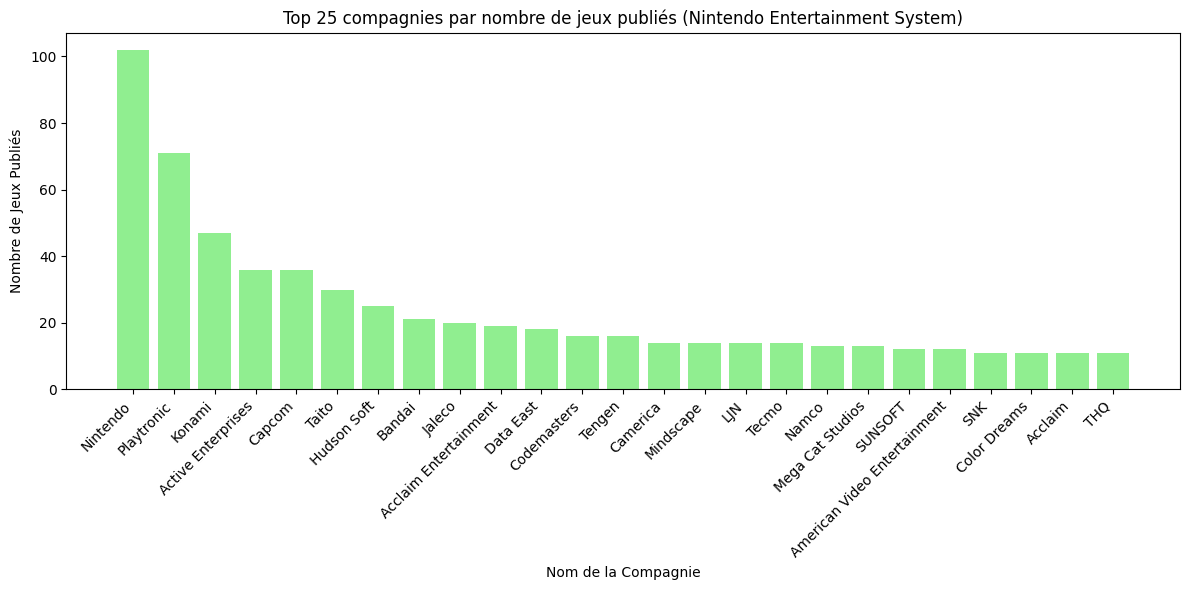

In [17]:
# Récupérer les données, les transformer si nécessaire, puis afficher sous forme de graphiques
import numpy as np
data_comp = requete_vers_dataframe(conn, f"""
    SELECT C.NomCompagnie, COUNT(DISTINCT J.IdJeu) AS nb_jeux_dev
    FROM {SCHEMA}.JEU J    
    INNER JOIN {SCHEMA}.COMPAGNIEJEU CJ ON CJ.IdJeu = J.IdJeu
    INNER JOIN {SCHEMA}.COMPAGNIE C ON CJ.IdCompagnie = C.IdCompagnie
    INNER JOIN {SCHEMA}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {SCHEMA}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    WHERE P.NomPlateforme = :plateforme
    GROUP BY C.NomCompagnie
    ORDER BY nb_jeux_dev DESC
    FETCH FIRST 25 ROWS ONLY
""", {"plateforme": NOM_PLATEFORME})

data_pub = requete_vers_dataframe(conn, f"""
    SELECT C.NomCompagnie, COUNT(DISTINCT J.IdJeu) AS nb_jeux_pub
    FROM {SCHEMA}.JEU J    
    INNER JOIN {SCHEMA}.COMPAGNIEJEU CJ ON CJ.IdJeu = J.IdJeu
    INNER JOIN {SCHEMA}.COMPAGNIE C ON CJ.IdCompagnie = C.IdCompagnie
    INNER JOIN {SCHEMA}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {SCHEMA}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    WHERE P.NomPlateforme = :plateforme
      AND CJ.ESTPUBLIEUR = 1
    GROUP BY C.NomCompagnie
    ORDER BY nb_jeux_pub DESC
    FETCH FIRST 25 ROWS ONLY
""", {"plateforme": NOM_PLATEFORME})


xpoint = np.array(data_comp['NOMCOMPAGNIE'][0:25].to_list())
ypoint = np.array(data_comp['NB_JEUX_DEV'][0:25].to_list())

plt.figure(figsize=(12, 6))
plt.bar(xpoint, ypoint, color='skyblue')
plt.xticks(rotation=45, ha='right') 
plt.xlabel("Nom de la Compagnie")
plt.ylabel("Nombre de Jeux Développés")
plt.title("Top 25 Compagnies par Nombre de Jeux Développés")
plt.tight_layout()  # Adjust layout to prevent clipping

# Save and show plot

plt.show()

xpoint = np.array(data_pub['NOMCOMPAGNIE'].to_list())
ypoint = np.array(data_pub['NB_JEUX_PUB'].to_list())

plt.figure(figsize=(12, 6))
plt.bar(xpoint, ypoint, color='lightgreen')
plt.xticks(rotation=45, ha='right') 
plt.xlabel("Nom de la Compagnie")
plt.ylabel("Nombre de Jeux Publiés")
plt.title(f"Top 25 compagnies par nombre de jeux publiés ({NOM_PLATEFORME})")
plt.tight_layout()
plt.show()

## Partie modification des données

Nombre de jeux sortis sur cette plateforme : 1403

Top 10 des jeux par Score IGDB (utilisateurs) :
              TITREJEU  SCOREIGDB
0       BDWarrior 2025     100.00
1        Jurassic Park      97.67
2           Life Force      96.98
3             Tetris 2      89.65
4  Super Mario Bros. 3      89.48
5   Clash at Demonhead      88.75
6             Arkanoid      88.29
7              Pac-Man      87.76
8        Banana Prince      87.06
9          StarTropics      86.89

Top 10 des jeux par Score Agrégé (critiques) :
                                    TITREJEU  SCOREAGREGEJEU
0                             BDWarrior 2025           100.0
1                         Disney's DuckTales            86.0
2                             Blaster Master            85.0
3                            Blazing Rangers            82.0
4                               Bomberman II            80.0
5                                   Gauntlet            80.0
6            Cybernoid: The Fighting Machine        

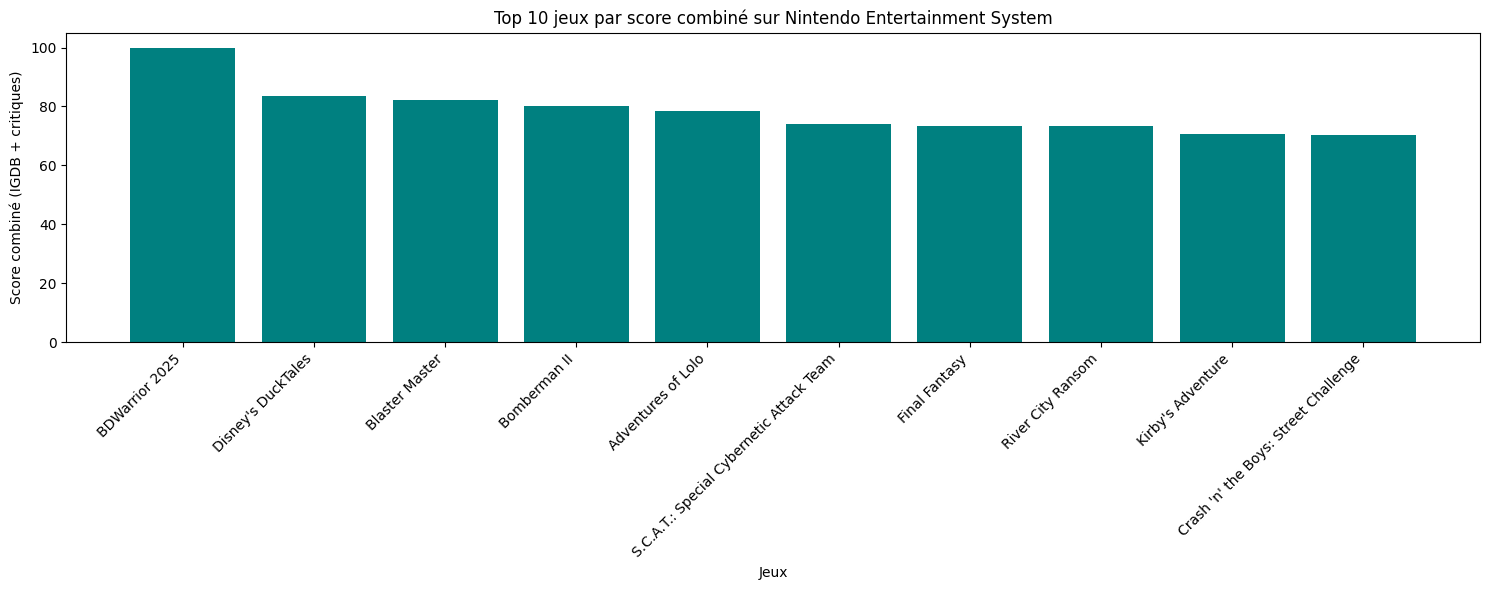

In [18]:
# Avant de commencer, on affiche le nombre de jeux sortis sur la plateforme et le top 10 des jeux les mieux notés par les utilisateurs, critiques et combinés sur la plateofme
import numpy as np
import matplotlib.pyplot as plt
import sys

# 1. Nombre de jeux sortis sur la plateforme
nb_jeu_plateforme = requete_vers_dataframe(conn, """ 
    SELECT COUNT(DISTINCT J.IdJeu) AS NB_JEUX
    FROM {1}.JEU J
    INNER JOIN {1}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {1}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    WHERE P.NomPlateforme = '{0}'
""".format(NOM_PLATEFORME, SCHEMA))
print(f"Nombre de jeux sortis sur cette plateforme : {nb_jeu_plateforme.iloc[0,0]}")

# 2. Top 10 jeux par Score IGDB
top_igdb = requete_vers_dataframe(conn, """
    SELECT TitreJeu, ROUND(AVG(ScoreIGDB), 2) AS ScoreIGDB
    FROM {1}.JEU J
    INNER JOIN {1}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {1}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    WHERE P.NomPlateforme = '{0}' AND ScoreIGDB IS NOT NULL
    GROUP BY TitreJeu
    ORDER BY ScoreIGDB DESC
    FETCH FIRST 10 ROWS ONLY
""".format(NOM_PLATEFORME, SCHEMA))
print("\nTop 10 des jeux par Score IGDB (utilisateurs) :")
print(top_igdb)
top_igdb = top_igdb[0:10]

# 3. Top 10 jeux par Score Agrégé
top_critiques = requete_vers_dataframe(conn, """
    SELECT TitreJeu, ROUND(AVG(ScoreAgregeJeu), 2) AS ScoreAgregeJeu
    FROM {1}.JEU J
    INNER JOIN {1}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {1}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    WHERE P.NomPlateforme = '{0}' AND ScoreAgregeJeu IS NOT NULL
    GROUP BY TitreJeu
    ORDER BY ScoreAgregeJeu DESC
    FETCH FIRST 10 ROWS ONLY
""".format(NOM_PLATEFORME, SCHEMA))
print("\nTop 10 des jeux par Score Agrégé (critiques) :")
print(top_critiques)
top_critiques = top_critiques[0:10]

# 4. Top 10 jeux par Score combiné
top_combine = requete_vers_dataframe(conn, """
    SELECT TitreJeu, 
           ROUND(AVG(ScoreIGDB), 2) AS ScoreIGDB,
           ROUND(AVG(ScoreAgregeJeu), 2) AS ScoreAgregeJeu,
           ROUND((AVG(ScoreIGDB) + AVG(ScoreAgregeJeu)) / 2, 2) AS ScoreCombine
    FROM {1}.JEU J
    INNER JOIN {1}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {1}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    WHERE P.NomPlateforme = '{0}' AND ScoreIGDB IS NOT NULL AND ScoreAgregeJeu IS NOT NULL
    GROUP BY TitreJeu
    ORDER BY ScoreCombine DESC
    FETCH FIRST 10 ROWS ONLY
""".format(NOM_PLATEFORME, SCHEMA))
print("\nTop 10 des jeux par Score Combiné (utilisateurs + critiques) :")
print(top_combine)

xpoint = np.array(top_combine['TITREJEU'][0:10].to_list())
ypoint = np.array(top_combine['SCORECOMBINE'][0:10].to_list())

plt.figure(figsize=(15, 6))
plt.bar(xpoint, ypoint, color='teal')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Jeux")
plt.ylabel("Score combiné (IGDB + critiques)")
plt.title("Top 10 jeux par score combiné sur {}".format(NOM_PLATEFORME))
plt.tight_layout()
plt.show()

### Ajout d'une nouvelle compagnie

Ajoutez à la base une nouvelle compagnie ayant pour nom *Binôme XXX* où XXX est votre numéro de binôme.

In [19]:
# Ajouter la compagnie ici
from datetime import datetime

dernier_id_df = requete_vers_dataframe(conn, f"SELECT MAX(IDCOMPAGNIE) FROM {SCHEMA}.COMPAGNIE")
dernier_id = int(dernier_id_df.iloc[0, 0]) + 1
print(f"Dernier Id: {dernier_id}")
date_maj = datetime.today().strftime('%d/%m/%y')
print(date_maj)

with Connexion(login=conn['login'], password=conn['password']) as connexion:
    connexion.begin()  
    curseur = connexion.cursor() 
    requete = f" INSERT INTO {SCHEMA}.COMPAGNIE(IDCOMPAGNIE, NOMCOMPAGNIE, DATEMAJCOMPAGNIE) VALUES({dernier_id}, 'Binôme 10', TO_DATE('{date_maj}', 'DD/MM/YY'))" 
    curseur.execute(requete) 
    connexion.commit() 

Dernier Id: 63086
19/06/25


### Ajout d'un nouveau jeu

Ajouter le nouveau jeu "BDWarrior 2025" développé et publié par la compagnie crée précédemment. Pour le moment, les scores et nombre de notes sont vides, et vous pouvez choisir les autres propriétés à votre goût.

In [20]:
# Ajouter le jeu ici
from datetime import datetime

dernier_id_df = requete_vers_dataframe(conn, f"SELECT MAX(IDJEU) FROM {SCHEMA}.JEU")
dernier_id_jeu = int(dernier_id_df.iloc[0, 0]) + 1
id_compagnie = 5 
date_maj = datetime.today().strftime('%d/%m/%y')
date_sortie = '01/06/25'
url = 'https://bdwarrior2025.example.com'
categorie_jeu = 1

with Connexion(login=conn['login'], password=conn['password']) as connexion:
    connexion.begin()
    curseur = connexion.cursor()
    
    insert_jeu_sql = f"""
    INSERT INTO {SCHEMA}.JEU (
        IDJEU, TITREJEU, TITREVERSIONJEU, HISTOIREJEU, RESUMEJEU, URLJEU,
        SCOREAGREGEJEU, NOMBRENOTESAGREGEESJEU, SCOREIGDB, NOMBRENOTESIGDBJEU,
        SCOREJEU, NOMBRENOTESJEU,
        TEMPSJEU_NORMAL, TEMPSJEU_RAPIDE, TEMPSJEU_COMPLET, NOMBRETEMPSJEU,
        STATUTJEU, DATEMAJJEU, CATEGORIEJEU
    )
    VALUES (
        {dernier_id_jeu}, 'BDWarrior 2025', 'Ultimate Edition',
        'Le héros combat pour la liberté dans un futur dystopique.',
        'Un beat em all futuriste en 2D.', '{url}',
        NULL, NULL, NULL, NULL, NULL, NULL,
        600, 1200, 1800, 152,
        'Sorti', TO_DATE('{date_maj}', 'DD/MM/YY'), {categorie_jeu}
    )
    """
    curseur.execute(insert_jeu_sql)
    
    insert_compagnie_sql = f"""
    INSERT INTO {SCHEMA}.COMPAGNIEJEU (
        IDJEU, IDCOMPAGNIE, ESTDEVELOPPEUR, ESTPORTEUR, ESTPUBLIEUR, ESTSOUTIEN
    )
    VALUES (
        {dernier_id_jeu}, {id_compagnie}, 1, 0, 1, 0
    )
    """
    curseur.execute(insert_compagnie_sql)
    
    themes_ids = [1, 17]
    for theme_id in themes_ids:
        insert_theme_sql = f"""
        INSERT INTO {SCHEMA}.THEMEJEU (IDTHEME, IDJEU)
        VALUES ({theme_id}, {dernier_id_jeu})
        """
        curseur.execute(insert_theme_sql)
    
    genres_ids = [4, 31] 
    for genre_id in genres_ids:
        insert_genre_sql = f"""
        INSERT INTO {SCHEMA}.GENREJEU (IDGENRE, IDJEU)
        VALUES ({genre_id}, {dernier_id_jeu})
        """
        curseur.execute(insert_genre_sql)
    
    regions_localisations = [
        (2, 'BDWarrior 2025'),
        (4, 'BDWarrior 2025'), 
        (3, 'コミックの戦士 2025')  
    ]
    for region_id, titre_localise in regions_localisations:
        insert_localisation_sql = f"""
        INSERT INTO {SCHEMA}.LOCALISATIONJEU (IDJEU, IDREGION, TITRELOCALISE)
        VALUES ({dernier_id_jeu}, {region_id}, '{titre_localise}')
        """
        curseur.execute(insert_localisation_sql)
    
    motscles_ids = [10162, 46222]
    for motcle_id in motscles_ids:
        insert_motcle_sql = f"""
        INSERT INTO {SCHEMA}.MOTCLEJEU (IDMOTCLE, IDJEU)
        VALUES ({motcle_id}, {dernier_id_jeu})
        """
        curseur.execute(insert_motcle_sql)
    
    modalites_ids = [1, 2]
    for modalite_id in modalites_ids:
        insert_modalite_sql = f"""
        INSERT INTO {SCHEMA}.MODALITEJEU (IDMODALITE, IDJEU)
        VALUES ({modalite_id}, {dernier_id_jeu})
        """
        curseur.execute(insert_modalite_sql)

    plateformes_dates = [
        (6, date_sortie, 'Monde'),    
        (49, '15/06/25', 'Monde'),    
        (169, '20/07/25', 'Monde')   
    ]
    
    dernier_id_date_df = requete_vers_dataframe(conn, f"SELECT MAX(IDDATESORTIE) FROM {SCHEMA}.DATESORTIE")
    dernier_id_date = int(dernier_id_date_df.iloc[0, 0]) + 1
    
    for i, (plateforme_id, date_sortie_plat, region_sortie) in enumerate(plateformes_dates):
        insert_datesortie_sql = f"""
        INSERT INTO {SCHEMA}.DATESORTIE (
            IDDATESORTIE, IDJEU, IDPLATEFORME, DATESORTIE, REGIONSORTIE, 
            STATUTSORTIE, DATEMAJDATESORTIE
        )
        VALUES (
            {dernier_id_date + i}, {dernier_id_jeu}, {plateforme_id}, 
            TO_DATE('{date_sortie_plat}', 'DD/MM/YY'), '{region_sortie}',
            'Confirmé', TO_DATE('{date_maj}', 'DD/MM/YY')
        )
        """
        curseur.execute(insert_datesortie_sql)
    
    dernier_id_multi_df = requete_vers_dataframe(conn, f"SELECT MAX(IDMODEMULTIJOUEUR) FROM {SCHEMA}.MODEMULTIJOUEUR")
    dernier_id_multi = int(dernier_id_multi_df.iloc[0, 0]) + 1
    
    insert_multi_sql = f"""
    INSERT INTO {SCHEMA}.MODEMULTIJOUEUR (
        IDMODEMULTIJOUEUR, DROPIN, MODECOOPCAMPAGNE, MODECOOPLAN,
        MODECOOPOFFLINE, MODECOOPONLINE, MODESPLITSCREEN,
        NBJOUEURSMAXCOOPOFFLINE, NBJOUEURSMAXOFFLINE,
        NBJOUEURSMAXCOOPONLINE, NBJOUEURSMAXONLINE,
        IDJEU, IDPLATEFORME
    )
    VALUES (
        {dernier_id_multi}, 0, 1, 0, 1, 1, 1,
        2, 2, 4, 8,
        {dernier_id_jeu}, 6
    )
    """
    curseur.execute(insert_multi_sql)
    
    dernier_id_titre_df = requete_vers_dataframe(conn, f"SELECT MAX(IDTITREALTERNATIF) FROM {SCHEMA}.TITREALTERNATIF")
    dernier_id_titre = int(dernier_id_titre_df.iloc[0, 0]) + 1
    
    titres_alternatifs = [
        'BD Warrior 2025',
        'Battle Dystopia Warrior 2025'
    ]
    
    for i, titre_alt in enumerate(titres_alternatifs):
        insert_titre_alt_sql = f"""
        INSERT INTO {SCHEMA}.TITREALTERNATIF (
            IDTITREALTERNATIF, LIBELLETITREALTERNATIF, IDJEU
        )
        VALUES (
            {dernier_id_titre + i}, '{titre_alt}', {dernier_id_jeu}
        )
        """
        curseur.execute(insert_titre_alt_sql)
    
    insert_popularite_sql = f"""
    INSERT INTO {SCHEMA}.POPULARITE (IDJEU, MESUREPOPULARITE, VALEURPOPULARITE)
    VALUES ({dernier_id_jeu}, 'hype', 0.85)
    """
    curseur.execute(insert_popularite_sql)
    
    connexion.commit()
    print(f"Jeu BDWarrior 2025 ajouté avec succès avec tous ses liens")
# Faire ensuite les liens avec les tables COMPAGNIE, THEME, CATEGORIEJEU, REGION, MOTCLE...

Jeu BDWarrior 2025 ajouté avec succès avec tous ses liens


### Ajout d'une nouvelle date de sortie

Le jeu est sorti mondialement le 28/05/2025 sur la plateforme qui vous a été assignée.

In [21]:
# Ajouter la sortie ici
from datetime import datetime

iddatesortie_df = requete_vers_dataframe(conn, f"SELECT MAX(IDDATESORTIE) FROM {SCHEMA}.DATESORTIE")
iddatesortie = int(iddatesortie_df.iloc[0, 0]) + 1
idjeu = dernier_id_jeu  
idplateforme = 18       
date_sortie = '28/05/25'
date_maj = datetime.today().strftime('%d/%m/%y')
region = 'Europe'
statut = 'Disponible'


with Connexion(login=conn['login'], password=conn['password']) as connexion:
    connexion.begin()  # Démarre une transaction
    curseur = connexion.cursor()  # On prépare un curseur pour exécuter une requête
    requete = f"""
    INSERT INTO {SCHEMA}.DATESORTIE (
        IDDATESORTIE, IDJEU, IDPLATEFORME, DATESORTIE, REGIONSORTIE, STATUTSORTIE, DATEMAJDATESORTIE
    ) VALUES (
        {iddatesortie}, {idjeu}, {idplateforme},
        TO_DATE('{date_sortie}', 'DD/MM/YY'),
        '{region}', '{statut}',
        TO_DATE('{date_maj}', 'DD/MM/YY')
    )"""
    curseur.execute(requete)  
    connexion.commit() 

### Affichage

In [29]:
# On affiche la fiche détaillée des sorties du jeu (avec DETAIL_SORTIES)
oracledb.defaults.fetch_lobs = False 

with Connexion(login=conn['login'], password=conn['password']) as connexion:
    curseur = connexion.cursor()

    requete = f"SELECT DETAIL_SORTIES({dernier_id_jeu}) FROM DUAL"
    curseur.execute(requete)

    resultat = curseur.fetchone()[0]
    print(resultat)

None


### Première vérification

On vérifie maintenant que le nombre de jeux sur la plateforme reflète l'ajout que l'on vient de faire.

In [23]:
# On affiche le nombre de jeux sortis sur la plateforme
data = requete_vers_dataframe(conn, f"""
SELECT COUNT(DISTINCT J.idJeu) as nb
FROM {SCHEMA}.JEU J
INNER JOIN {SCHEMA}.DATESORTIE DS ON J.idJeu=DS.idJeu
INNER JOIN {SCHEMA}.PLATEFORME P ON DS.idPlateforme=P.idPlateforme
WHERE nomPlateforme='Nintendo Entertainment System'""")  
print(data);

     NB
0  1404


### Evaluation du jeu

Votre jeu est un immense succès, il obtient une note parfaite tant chez les utilisateurs que chez les critiques. Mettez à jour la base pour refléter cela.

In [24]:
# Faire la mise à jour des notes
from datetime import datetime

with Connexion(login=conn['login'], password=conn['password']) as connexion:
    connexion.begin()  # Démarre une transaction
    curseur = connexion.cursor()  # On prépare un curseur pour exécuter une requête
    requete = f"UPDATE {SCHEMA}.JEU SET ScoreAgregeJeu = 100 WHERE IdJeu = {idjeu}"
    requete2 = f"UPDATE {SCHEMA}.JEU SET ScoreJeu = 100 WHERE IdJeu = {idjeu}"
    requete3 = f"UPDATE {SCHEMA}.JEU SET ScoreIGDB = 100 WHERE IdJeu = {idjeu}"
    #donnees = {'id':999999, 'nom':"Mon nom"}  # Les données à insérer pour cette requête
    curseur.execute(requete)  # On demande au serveur d'exécuter la requête
    curseur.execute(requete2)
    curseur.execute(requete3)
    connexion.commit()  # On valide la transaction

### Seconde vérification

On regarde maintenant le top 10 des jeux les mieux notés sur les trois critères sur la plateforme


Top 10 des jeux par Score IGDB (utilisateurs) :
              TITREJEU  SCOREIGDB
0       BDWarrior 2025     100.00
1        Jurassic Park      97.67
2           Life Force      96.98
3             Tetris 2      89.65
4  Super Mario Bros. 3      89.48
5   Clash at Demonhead      88.75
6             Arkanoid      88.29
7              Pac-Man      87.76
8        Banana Prince      87.06
9          StarTropics      86.89

Top 10 des jeux par Score Agrégé (critiques) :
                                    TITREJEU  SCOREAGREGEJEU
0                             BDWarrior 2025           100.0
1                         Disney's DuckTales            86.0
2                             Blaster Master            85.0
3                            Blazing Rangers            82.0
4                               Bomberman II            80.0
5                                   Gauntlet            80.0
6            Cybernoid: The Fighting Machine            80.0
7   S.C.A.T.: Special Cybernetic Attack T

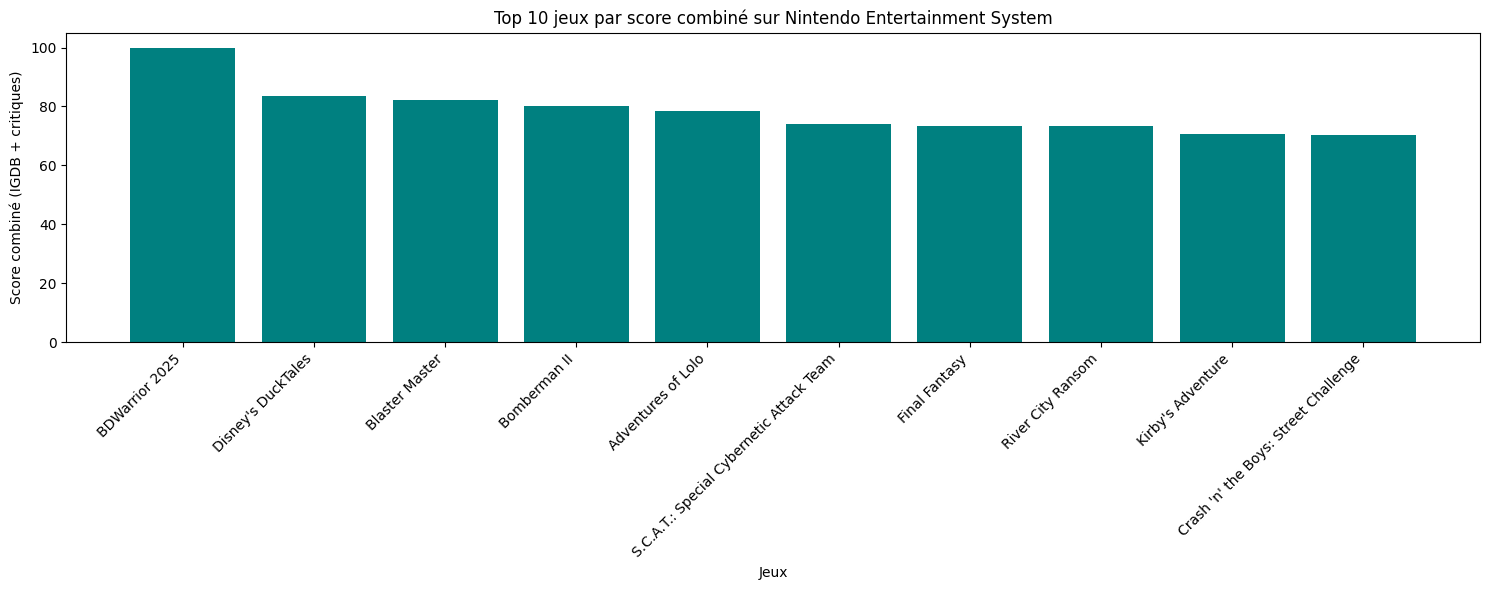

In [25]:
# Afficher les nouveaux top 10 ici
# 2. Top 10 jeux par Score IGDB
top_igdb = requete_vers_dataframe(conn, """
    SELECT TitreJeu, ROUND(AVG(ScoreIGDB), 2) AS ScoreIGDB
    FROM {1}.JEU J
    INNER JOIN {1}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {1}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    WHERE P.NomPlateforme = '{0}' AND ScoreIGDB IS NOT NULL
    GROUP BY TitreJeu
    ORDER BY ScoreIGDB DESC
    FETCH FIRST 10 ROWS ONLY
""".format(NOM_PLATEFORME, SCHEMA))
print("\nTop 10 des jeux par Score IGDB (utilisateurs) :")
print(top_igdb)
top_igdb = top_igdb[0:10]

# 3. Top 10 jeux par Score Agrégé
top_critiques = requete_vers_dataframe(conn, """
    SELECT TitreJeu, ROUND(AVG(ScoreAgregeJeu), 2) AS ScoreAgregeJeu
    FROM {1}.JEU J
    INNER JOIN {1}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {1}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    WHERE P.NomPlateforme = '{0}' AND ScoreAgregeJeu IS NOT NULL
    GROUP BY TitreJeu
    ORDER BY ScoreAgregeJeu DESC
    FETCH FIRST 10 ROWS ONLY
""".format(NOM_PLATEFORME, SCHEMA))
print("\nTop 10 des jeux par Score Agrégé (critiques) :")
print(top_critiques)
top_critiques = top_critiques[0:10]

# 4. Top 10 jeux par Score combiné
top_combine = requete_vers_dataframe(conn, """
    SELECT TitreJeu, 
           ROUND(AVG(ScoreIGDB), 2) AS ScoreIGDB,
           ROUND(AVG(ScoreAgregeJeu), 2) AS ScoreAgregeJeu,
           ROUND((AVG(ScoreIGDB) + AVG(ScoreAgregeJeu)) / 2, 2) AS ScoreCombine
    FROM {1}.JEU J
    INNER JOIN {1}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {1}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    WHERE P.NomPlateforme = '{0}' AND ScoreIGDB IS NOT NULL AND ScoreAgregeJeu IS NOT NULL
    GROUP BY TitreJeu
    ORDER BY ScoreCombine DESC
    FETCH FIRST 10 ROWS ONLY
""".format(NOM_PLATEFORME, SCHEMA))
print("\nTop 10 des jeux par Score Combiné (utilisateurs + critiques) :")
print(top_combine)

# Take only the first 10 games (or however many are available)
xpoint = np.array(top_combine['TITREJEU'][0:10].to_list())
ypoint = np.array(top_combine['SCORECOMBINE'][0:10].to_list())

plt.figure(figsize=(15, 6))
plt.bar(xpoint, ypoint, color='teal')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Jeux")
plt.ylabel("Score combiné (IGDB + critiques)")
plt.title("Top 10 jeux par score combiné sur {}".format(NOM_PLATEFORME))
plt.tight_layout()
plt.show()

### Nettoyage

Annulez maintenant vos modifications

In [26]:
# Nettoyage de la base ici (avec des requêtes DELETE)

id_jeu_a_supprimer = dernier_id_jeu
with Connexion(login=conn['login'], password=conn['password']) as connexion:
        connexion.begin()
        curseur = connexion.cursor()
        try: #on met un try au cass ou ca marche pas que ca fait pas une erreur
            delete_titres_sql = f"""
            DELETE FROM {SCHEMA}.TITREALTERNATIF 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_titres_sql)
            
            delete_popularite_sql = f"""
            DELETE FROM {SCHEMA}.POPULARITE 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_popularite_sql)
            
            delete_multi_sql = f"""
            DELETE FROM {SCHEMA}.MODEMULTIJOUEUR 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_multi_sql)
            
            # 4. Supprimer les dates de sortie
            delete_dates_sql = f"""
            DELETE FROM {SCHEMA}.DATESORTIE 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_dates_sql)
            
            delete_modalites_sql = f"""
            DELETE FROM {SCHEMA}.MODALITEJEU 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_modalites_sql)
            
            delete_motscles_sql = f"""
            DELETE FROM {SCHEMA}.MOTCLEJEU 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_motscles_sql)
            
            delete_localisations_sql = f"""
            DELETE FROM {SCHEMA}.LOCALISATIONJEU 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_localisations_sql)
            
            delete_genres_sql = f"""
            DELETE FROM {SCHEMA}.GENREJEU 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_genres_sql)
            
            delete_themes_sql = f"""
            DELETE FROM {SCHEMA}.THEMEJEU 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_themes_sql)
            
            delete_compagnies_sql = f"""
            DELETE FROM {SCHEMA}.COMPAGNIEJEU 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_compagnies_sql)
            
            delete_franchises_sql = f"""
            DELETE FROM {SCHEMA}.FRANCHISEJEU 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_franchises_sql)
            
            delete_moteurs_sql = f"""
            DELETE FROM {SCHEMA}.MOTEURJEU 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_moteurs_sql)
            
            delete_classifications_sql = f"""
            DELETE FROM {SCHEMA}.CLASSIFICATIONJEU 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_classifications_sql)
            
            delete_similarites_sql = f"""
            DELETE FROM {SCHEMA}.SIMILARITE 
            WHERE IDJEU = {id_jeu_a_supprimer} OR IDJEUSIMILAIRE = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_similarites_sql)
            
            delete_jeu_sql = f"""
            DELETE FROM {SCHEMA}.JEU 
            WHERE IDJEU = {id_jeu_a_supprimer}
            """
            curseur.execute(delete_jeu_sql)
            
            connexion.commit()
            print(f"Jeu avec l'ID {id_jeu_a_supprimer} supprimé complètement avec tous ses liens!")
            
        except Exception as e:
            print(f"Erreur lors de la suppression: {e}")
            raise

Jeu avec l'ID 340386 supprimé complètement avec tous ses liens!
